# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## REDES NEURONALES
## LABORATORIO 1/4

**NOMBRES:**
1. Ignacio Castillo

2. Mariana Malagón

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

*Incluya en este apartado el proceso de la derivación de las funciones*

---
**Derivada función Sigmoide:**

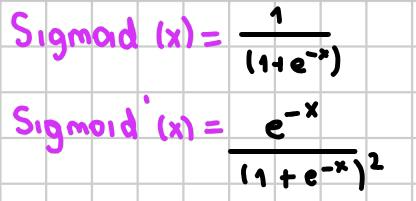


---
**Derivada función ReLU**

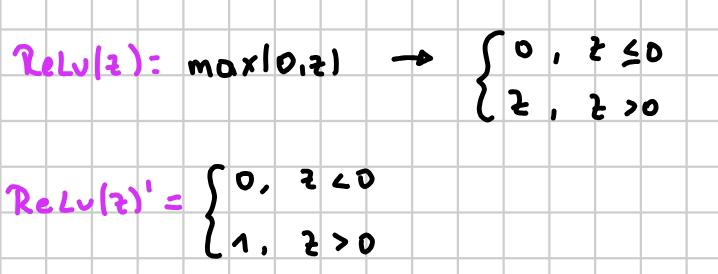

---
**Derivada función de costo: Entropia Cruzada**

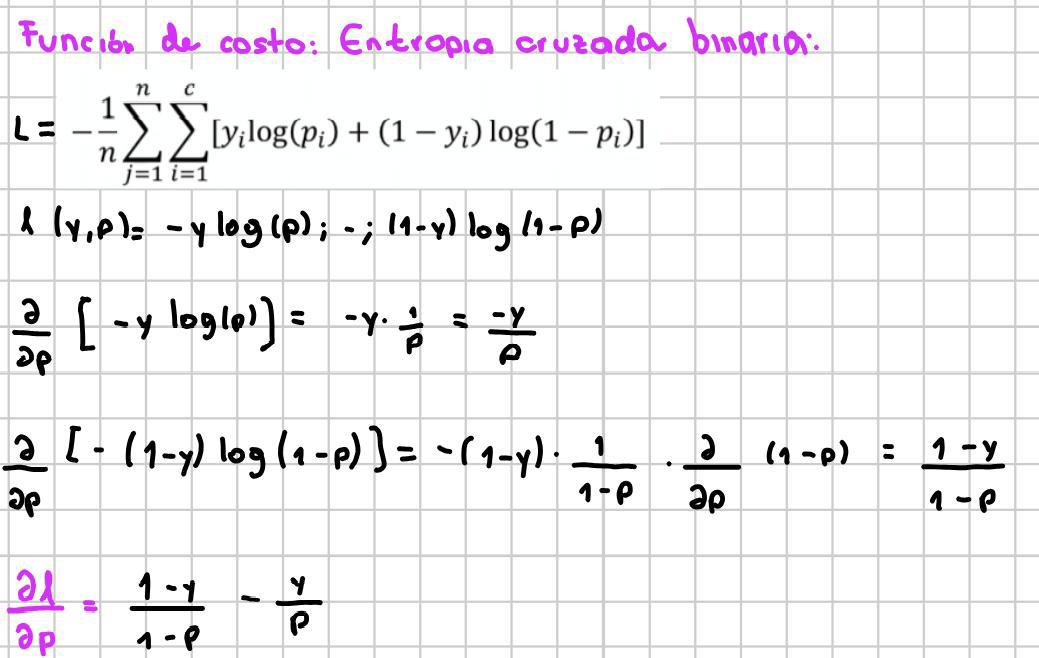


## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [ ]:
import numpy as np
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

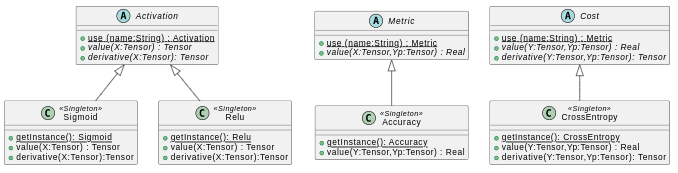

###MÉTRICA

In [ ]:
class Metric(ABC):
    """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier metrica """

    def use(self, name: str) -> "Metric":
        """ obtiene metrica (OBJ) a partir del nombre """
        name = name.lower().strip()
        if name in ["accuracy", "acc", "exactitud"]:
            return Accuracy()
        raise ValueError(f"Métrica no soportada: {name}")

    def value(self, Y: np.ndarray, Yp: np.ndarray):
        """ computa el desempeño (accuracy) de la red (> 0.6 es 1) """
        raise NotImplementedError("Metric.value debe ser implementado")


In [ ]:
# Documentar los métodos implementados
class Accuracy(Metric):
    """ Metrica de exactitud (acertados / totales). Implementa Metric """

    def Accuracy(self):
        pass

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        Y = np.asarray(Y).reshape(-1)
        Yp = np.asarray(Yp).reshape(-1)

        Yp_class = (Yp > 0.6).astype(int)


        Y_class = (Y > 0.5).astype(int)

        return float(np.mean(Yp_class == Y_class))

In [ ]:
# Adicione los casos de prueba de los métodos implementados

# Caso 1: todos correctos con umbral > 0.6
metric = Metric().use("accuracy")

Y  = np.array([0, 1, 1, 0])
Yp = np.array([0.1, 0.9, 0.61, 0.2])   # -> [0,1,1,0]
print("Accuracy caso 1 (esperado 1.0):", metric.value(Y, Yp))

# Caso 2: prueba exacta del borde (0.6 NO cuenta como 1)
Y  = np.array([0, 1, 1, 0])
Yp = np.array([0.6, 0.6000001, 0.59, 0.2])  # -> [0,1,0,0]
# aciertos: pos0 ok (0), pos1 ok (1), pos2 mal (esperado 1), pos3 ok (0) => 3/4 = 0.75
print("Accuracy caso 2 (esperado 0.75):", metric.value(Y, Yp))

# Caso 3: entradas como columna (n,1)
Y  = np.array([[0],[1],[0],[1]])
Yp = np.array([[0.2],[0.7],[0.8],[0.65]])   # -> [0,1,1,1] => aciertos: 3/4 = 0.75
print("Accuracy caso 3 (esperado 0.75):", metric.value(Y, Yp))

Accuracy caso 1 (esperado 1.0): 1.0
Accuracy caso 2 (esperado 0.75): 0.75
Accuracy caso 3 (esperado 0.75): 0.75


###COSTO

In [ ]:
class Cost(ABC):
    """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de costo """

    def use(self, name: str) -> "Cost":
        """ obtiene función de costo (OBJ) a partir del nombre """
        name = name.lower().strip()
        if name in ["crossentropy", "cross-entropy", "entropia", "entropia cruzada", "ce", "bce"]:
            return CrossEntropy()
        raise ValueError(f"Función de costo no soportada: {name}")

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        raise NotImplementedError("Cost.value debe ser implementado")

    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        raise NotImplementedError("Cost.derivative debe ser implementado")

In [ ]:
# Documentar los métodos implementados
class CrossEntropy(Cost):
    """ Función de costo Entropía Cruzada. Implementa Cost """

    def CrossEntropy(self):
        pass

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        Y = np.asarray(Y)
        Yp = np.asarray(Yp)

        eps = 1e-12
        Yp = np.clip(Yp, eps, 1.0 - eps)

        loss = -(Y * np.log(Yp) + (1.0 - Y) * np.log(1.0 - Yp))

        return float(np.mean(loss))

    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        Y = np.asarray(Y)
        Yp = np.asarray(Yp)

        eps = 1e-12
        Yp = np.clip(Yp, eps, 1.0 - eps)

        dL_dp = (1.0 - Y) / (1.0 - Yp) - (Y / Yp)

        n = Y.shape[0] if Y.ndim > 0 else 1
        dL_dp = dL_dp / n

        return dL_dp

In [ ]:
# Adicione los casos de prueba de los métodos implementados
cost = Cost().use("crossentropy")

# Caso 1: buenas predicciones -> loss baja
Y  = np.array([[0],[1],[1],[0]], dtype=float)
Yp = np.array([[0.01],[0.99],[0.90],[0.10]], dtype=float)
L1 = cost.value(Y, Yp)
d1 = cost.derivative(Y, Yp)
print("CE caso 1 (debe ser baja):", L1)
print("derivative shape:", d1.shape, " | finite:", np.isfinite(d1).all())

# Caso 2: malas predicciones con alta confianza -> loss alta
Y  = np.array([[0],[1]], dtype=float)
Yp = np.array([[0.99],[0.01]], dtype=float)
L2 = cost.value(Y, Yp)
d2 = cost.derivative(Y, Yp)
print("CE caso 2 (debe ser alta):", L2)
print("derivative shape:", d2.shape, " | finite:", np.isfinite(d2).all())

# Caso 3: valores extremos (0 o 1) para verificar el clip (no debe explotar)
Y  = np.array([[1],[0]], dtype=float)
Yp = np.array([[1.0],[0.0]], dtype=float)  # si no hay clip, log(0) revienta
L3 = cost.value(Y, Yp)
d3 = cost.derivative(Y, Yp)
print("CE caso 3 (debe ser finita por el clip):", L3)
print("derivative finite:", np.isfinite(d3).all())

CE caso 1 (debe ser baja): 0.05770542575566387
derivative shape: (4, 1)  | finite: True
CE caso 2 (debe ser alta): 4.605170185988091
derivative shape: (2, 1)  | finite: True
CE caso 3 (debe ser finita por el clip): 9.999778782803785e-13
derivative finite: True


###ACTIVACION

In [ ]:
class Activation(ABC):
    """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de activación """

    def use(self, name: str) -> "Activation":
        """ obtiene función de activación (OBJ) a partir del nombre """
        name = name.lower().strip()
        if name in ["sigmoid", "logistic"]:
            return Sigmoid()
        if name in ["relu"]:
            return Relu()
        raise ValueError(f"Función de activación no soportada: {name}")

    def value(self, X: np.ndarray) -> np.ndarray:
        raise NotImplementedError("Activation.value debe ser implementado")

    def derivative(self, X: np.ndarray) -> np.ndarray:
        raise NotImplementedError("Activation.derivative debe ser implementado")


In [ ]:
# Documentar los métodos implementados
class Sigmoid(Activation):
    """ Función de activación sigmoide. Implementa Activación """

    def Sigmoid(self):
        pass

    def value(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        # estable numéricamente
        out = np.empty_like(X, dtype=float)
        pos = X >= 0
        neg = ~pos
        out[pos] = 1.0 / (1.0 + np.exp(-X[pos]))
        expx = np.exp(X[neg])
        out[neg] = expx / (1.0 + expx)
        return out

    def derivative(self, X: np.ndarray) -> np.ndarray:
        S = self.value(X)
        return S * (1.0 - S)

In [ ]:
# Documentar los métodos implementados
class Relu(Activation):
    """ Función de activación RELU. Implementa Activación """

    def Relu(self):
        pass

    def value(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        return np.maximum(0.0, X)

    def derivative(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        return (X > 0.0).astype(float)

In [ ]:
# Adicione los casos de prueba de los métodos implementados
import numpy as np

sig = Activation().use("sigmoid")
relu = Activation().use("relu")

X = np.array([[-2.0], [0.0], [2.0]])

# Sigmoid
S = sig.value(X)
dS = sig.derivative(X)
print("Sigmoid(X):\n", S)
print("Sigmoid'(X):\n", dS)
print("Sigmoid(0) esperado 0.5 ->", S[1].item())

# ReLU
R = relu.value(X)
dR = relu.derivative(X)
print("ReLU(X):\n", R)
print("ReLU'(X):\n", dR)

# chequeos rápidos
assert np.all(R[X <= 0] == 0), "ReLU debe dar 0 en X<=0"
assert dR[0].item() == 0.0 and dR[2].item() == 1.0, "ReLU' debe ser 0 en negativos y 1 en positivos"
assert np.isfinite(S).all() and np.isfinite(dS).all(), "Sigmoid no debe producir NaN/Inf"

Sigmoid(X):
 [[0.11920292]
 [0.5       ]
 [0.88079708]]
Sigmoid'(X):
 [[0.10499359]
 [0.25      ]
 [0.10499359]]
Sigmoid(0) esperado 0.5 -> 0.5
ReLU(X):
 [[0.]
 [0.]
 [2.]]
ReLU'(X):
 [[0.]
 [0.]
 [1.]]


## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

---
**Gradiente dW**

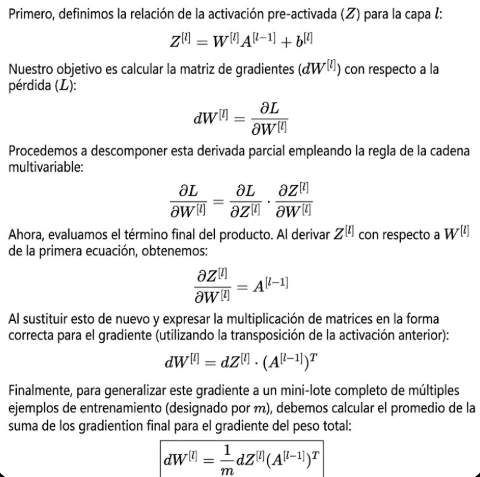

---
**Graciente db**

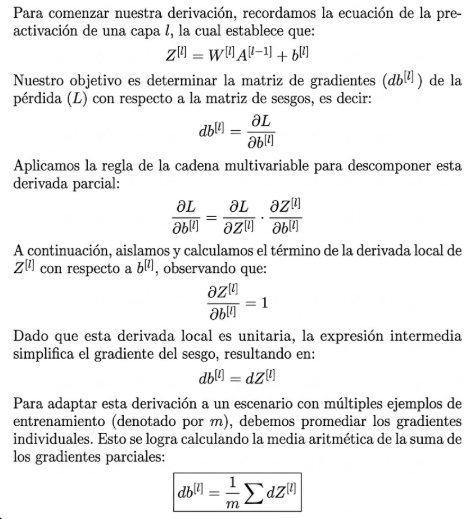


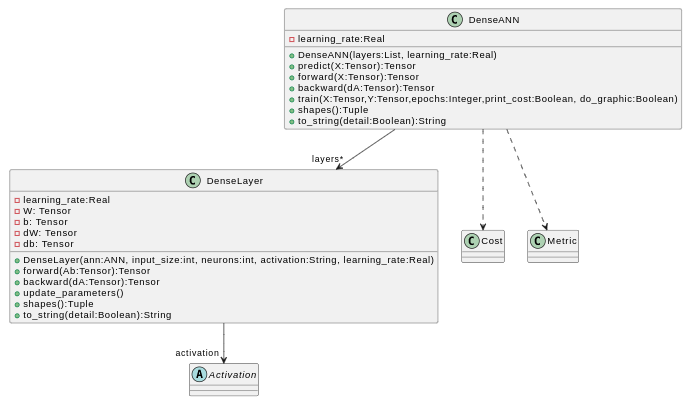

In [ ]:
class DenseANN:
    """Representa una red neuronal totalmente conectada"""

    def __init__(self, layers: list, learning_rate: float):
        """
        Inicializa la red neuronal creando las capas densas.
        Args:
            layers (list): [c, n1, n2, ..., salida]
                           layers[0] = nº características de entrada
                           layers[-1] = nº neuronas de salida
            learning_rate (float): eta tasa de aprendizaje
        """
        self.learning_rate = learning_rate
        self.layers_sizes = layers
        self.L = len(layers) - 1   # número de capas con parámetros

        self.dense_layers = []
        for i in range(self.L):
            input_size = layers[i]
            neurons    = layers[i + 1]
            # ReLU en capas ocultas, Sigmoid en la capa de salida
            activation = "relu" if i < self.L - 1 else "sigmoid"
            layer = DenseLayer(input_size, neurons, activation, learning_rate)
            self.dense_layers.append(layer)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Genera una predicción para X usando el estado actual de los pesos.
        Args:
            X (np.ndarray): entradas (c, m)
        Returns:
            Yp (np.ndarray): salidas estimadas (salida, m)
        """
        return self.forward(X)

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Computa hacia adelante un ciclo de entradas a través de la red.
        Args:
            X (np.ndarray): valores de características (c, m)
        Returns:
            Yp (np.ndarray): valores de salidas obtenidas (salida, m)
        """
        A = X
        for layer in self.dense_layers:
            A = layer.forward(A)
        return A

    def backward(self, dA: np.ndarray) -> np.ndarray:
        """
        Computa hacia atrás los errores y gradientes por toda la red.
        Args:
            dA (np.ndarray): gradiente inicial desde la función de costo (salida, m)
        Returns:
            dA (np.ndarray): gradiente propagado hasta la entrada
        """
        for layer in reversed(self.dense_layers):
            dA = layer.backward(dA)
        return dA

    def train(self, X: np.ndarray, Y: np.ndarray,
              epochs: int, print_cost: bool = True, do_graphic: bool = True):
        """
        Entrena la red neuronal con descenso de gradiente por backpropagation.
        Args:
            X (np.ndarray): valores de características (c, m)
            Y (np.ndarray): valores de salidas esperadas (salida, m)
            epochs (int): número de iteraciones
            print_cost (bool): mostrar el costo por iteración
            do_graphic (bool): graficar el costo por iteración
        """
        import matplotlib.pyplot as plt

        cost_fn   = Cost().use("crossentropy")
        metric_fn = Metric().use("accuracy")

        history_cost   = []
        history_metric = []

        for epoch in range(1, epochs + 1):

            # Forward
            Yp = self.forward(X)

            # Costo y métrica
            c = cost_fn.value(Y, Yp)
            a = metric_fn.value(Y, Yp)
            history_cost.append(c)
            history_metric.append(a)

            # Backward
            dA = cost_fn.derivative(Y, Yp)
            self.backward(dA)

            # Imprimir progreso
            if print_cost and epoch % 100 == 0:
                print(f"Época {epoch:>5} | Costo: {c:.6f} | Accuracy: {a:.4f}")

        # Gráfica de curva de aprendizaje
        if do_graphic:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            axes[0].plot(history_cost, color="steelblue")
            axes[0].set_title("Curva de aprendizaje — Costo")
            axes[0].set_xlabel("Época")
            axes[0].set_ylabel("Cross-Entropy")
            axes[0].grid(True)

            axes[1].plot(history_metric, color="darkorange")
            axes[1].set_title("Curva de aprendizaje — Accuracy")
            axes[1].set_xlabel("Época")
            axes[1].set_ylabel("Accuracy")
            axes[1].set_ylim(0, 1.05)
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()

        return {"cost": history_cost, "metric": history_metric}

    def shapes(self):
        """
        Genera los valores asociados al tamaño de la red.
        Returns:
            s (tuple): arquitectura de la red como tupla
        """
        return tuple(self.layers_sizes)

    def to_string(self, detail: bool = False):
        """
        Representación en texto de la red completa.
        Args:
            detail (bool): si True, muestra detalle de cada capa
        """
        print(f"DenseANN | capas: {self.L} | arquitectura: {self.layers_sizes} | lr: {self.learning_rate}")
        for i, layer in enumerate(self.dense_layers):
            print(f"  Capa {i+1}:", end=" ")
            layer.to_string(detail=detail)

## CAPA CON PERCEPTRONES

In [ ]:
class DenseLayer:
    """Representa una capa (oculta o salida) en la red neuronal"""

    def __init__(self, input_size: int, neurons: int, activation: str, learning_rate: float):
        """
        Inicializa una capa de neuronas dentro de la red neuronal.
        Args:
            input_size (int): número de neuronas de capa anterior o de atributos de entrada
            neurons (int): número de neuronas en la capa
            activation (str): nombre de la función de activación
            learning_rate (float): eta tasa de aprendizaje
        """
        self.neurons = neurons
        self.input_size = input_size
        self.activation = Activation().use(activation)
        self.learning_rate = learning_rate

        # Inicialización He para ReLU, Xavier para Sigmoid
        if activation in ["relu"]:
            scale = np.sqrt(2.0 / input_size)
        else:
            scale = np.sqrt(1.0 / input_size)

        # W shape: (neurons, input_size) | b shape: (neurons, 1)
        self.W = np.random.randn(neurons, input_size) * scale
        self.b = np.zeros((neurons, 1))

        # Caché para backprop
        self.X_in = None   # entrada guardada en forward
        self.Z    = None   # suma ponderada guardada en forward
        self.dW   = None   # gradiente de W (calculado en backward)
        self.db   = None   # gradiente de b (calculado en backward)

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Paso hacia adelante: calcula la activación de la capa.
        Args:
            X (np.ndarray): entrada de shape (input_size, m)
        Returns:
            np.ndarray: salida de shape (neurons, m)
        """
        self.X_in = X                           # guardar para backprop
        self.Z    = self.W @ X + self.b         # (neurons, m)
        return self.activation.value(self.Z)    # (neurons, m)

    def backward(self, dA: np.ndarray) -> np.ndarray:
        """
        Paso hacia atrás: calcula gradientes y llama a update_parameters.
        Args:
            dA (np.ndarray): gradiente de la pérdida respecto a la salida, shape (neurons, m)
        Returns:
            np.ndarray: gradiente respecto a la entrada X, shape (input_size, m)
        """
        m = self.X_in.shape[1]

        # Gradiente respecto a Z (regla de la cadena con la activación)
        dZ = dA * self.activation.derivative(self.Z)   # (neurons, m)

        # Guardar gradientes de W y b
        self.dW = (dZ @ self.X_in.T) / m               # (neurons, input_size)
        self.db = np.sum(dZ, axis=1, keepdims=True) / m # (neurons, 1)

        # Gradiente que se propaga hacia la capa anterior
        dX = self.W.T @ dZ                              # (input_size, m)

        # Actualizar parámetros
        self.update_parameters()

        return dX

    def update_parameters(self):
        """
        Actualiza los parámetros de la capa a partir del gradiente.
        """
        self.W -= self.learning_rate * self.dW
        self.b -= self.learning_rate * self.db

    def shapes(self):
        """
        Genera los valores asociados al tamaño de la capa.
        Returns:
            s (tuple): (neurons, input_size) — forma de la matriz de pesos W
        """
        return (self.neurons, self.input_size)

    def to_string(self, detail: bool = False):
        """
        Representación en texto de la capa.
        Args:
            detail (bool): si True, muestra también los valores de W y b
        """
        info = (f"DenseLayer | neuronas: {self.neurons} | "
                f"entrada: {self.input_size} | "
                f"activación: {type(self.activation).__name__} | "
                f"lr: {self.learning_rate}")
        if detail:
            info += f"\n  W shape: {self.W.shape}\n  b shape: {self.b.shape}"
        print(info)

Época   100 | Costo: 0.226698 | Accuracy: 1.0000
Época   200 | Costo: 0.142694 | Accuracy: 1.0000
Época   300 | Costo: 0.103861 | Accuracy: 1.0000
Época   400 | Costo: 0.081340 | Accuracy: 1.0000
Época   500 | Costo: 0.066671 | Accuracy: 1.0000
Época   600 | Costo: 0.056386 | Accuracy: 1.0000
Época   700 | Costo: 0.048791 | Accuracy: 1.0000
Época   800 | Costo: 0.042964 | Accuracy: 1.0000
Época   900 | Costo: 0.038356 | Accuracy: 1.0000
Época  1000 | Costo: 0.034625 | Accuracy: 1.0000


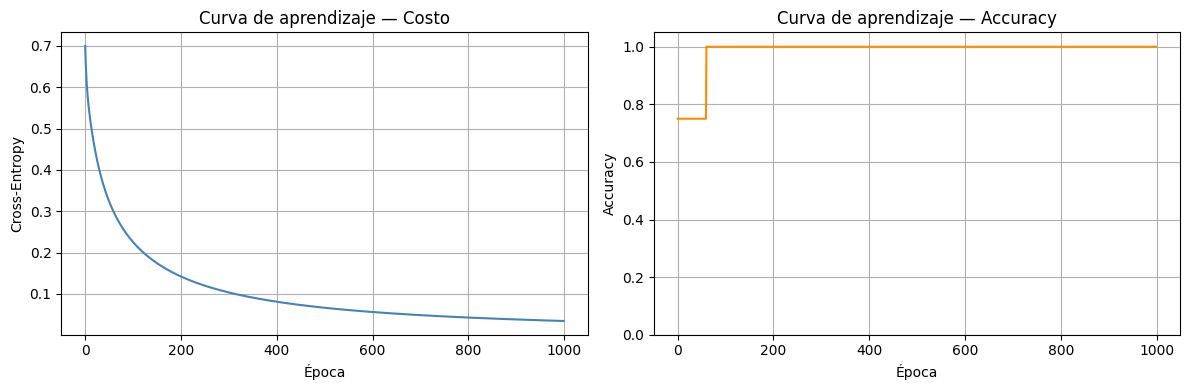


Predicciones AND:
  0 AND 0 -> 0.0001 (esperado 0)
  0 AND 1 -> 0.0397 (esperado 0)
  1 AND 0 -> 0.0397 (esperado 0)
  1 AND 1 -> 0.9444 (esperado 1)


In [ ]:
# Caso 1: operador lógico AND
# Un perceptrón SÍ puede aprender AND porque es linealmente separable

np.random.seed(42)

X_and = np.array([[0,0,1,1],
                   [0,1,0,1]], dtype=float)   # (2, 4)
Y_and = np.array([[0,0,0,1]], dtype=float)    # (1, 4)

ann_and = DenseANN(layers=[2, 1], learning_rate=0.5)
ann_and.train(X_and, Y_and, epochs=1000, print_cost=True, do_graphic=True)

print("\nPredicciones AND:")
Yp = ann_and.predict(X_and)
for i in range(4):
    print(f"  {int(X_and[0,i])} AND {int(X_and[1,i])} -> {Yp[0,i]:.4f} (esperado {int(Y_and[0,i])})")

Época   100 | Costo: 0.154943 | Accuracy: 1.0000
Época   200 | Costo: 0.089276 | Accuracy: 1.0000
Época   300 | Costo: 0.061769 | Accuracy: 1.0000
Época   400 | Costo: 0.046917 | Accuracy: 1.0000
Época   500 | Costo: 0.037700 | Accuracy: 1.0000
Época   600 | Costo: 0.031453 | Accuracy: 1.0000
Época   700 | Costo: 0.026951 | Accuracy: 1.0000
Época   800 | Costo: 0.023560 | Accuracy: 1.0000
Época   900 | Costo: 0.020915 | Accuracy: 1.0000
Época  1000 | Costo: 0.018798 | Accuracy: 1.0000


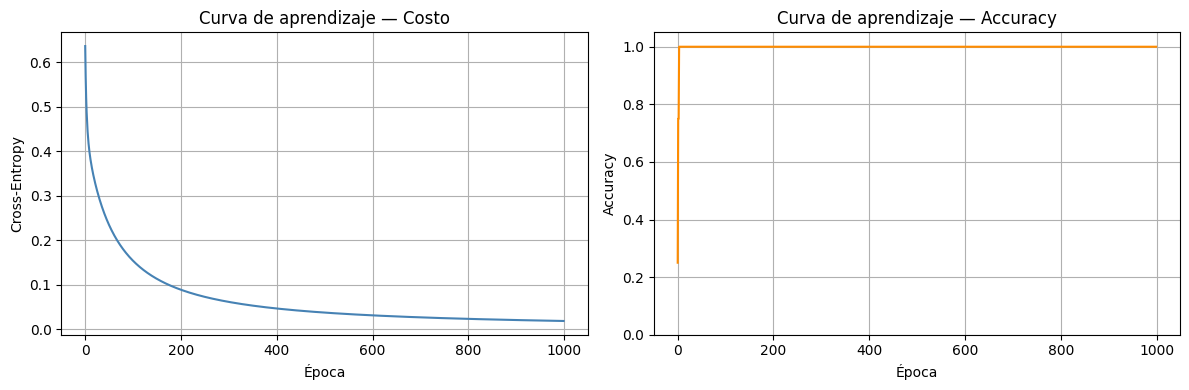


Predicciones OR:
  0 OR 0 -> 0.0412 (esperado 0)
  0 OR 1 -> 0.9836 (esperado 1)
  1 OR 0 -> 0.9836 (esperado 1)
  1 OR 1 -> 1.0000 (esperado 1)


In [ ]:
# Caso 2: operador lógico OR
# Un perceptrón SÍ puede aprender OR porque es linealmente separable

np.random.seed(42)

X_or = np.array([[0,0,1,1],
                  [0,1,0,1]], dtype=float)    # (2, 4)
Y_or = np.array([[0,1,1,1]], dtype=float)     # (1, 4)

ann_or = DenseANN(layers=[2, 1], learning_rate=0.5)
ann_or.train(X_or, Y_or, epochs=1000, print_cost=True, do_graphic=True)

print("\nPredicciones OR:")
Yp = ann_or.predict(X_or)
for i in range(4):
    print(f"  {int(X_or[0,i])} OR {int(X_or[1,i])} -> {Yp[0,i]:.4f} (esperado {int(Y_or[0,i])})")

Época   100 | Costo: 0.693160 | Accuracy: 0.5000
Época   200 | Costo: 0.693147 | Accuracy: 0.5000
Época   300 | Costo: 0.693147 | Accuracy: 0.5000
Época   400 | Costo: 0.693147 | Accuracy: 0.5000
Época   500 | Costo: 0.693147 | Accuracy: 0.5000
Época   600 | Costo: 0.693147 | Accuracy: 0.5000
Época   700 | Costo: 0.693147 | Accuracy: 0.5000
Época   800 | Costo: 0.693147 | Accuracy: 0.5000
Época   900 | Costo: 0.693147 | Accuracy: 0.5000
Época  1000 | Costo: 0.693147 | Accuracy: 0.5000


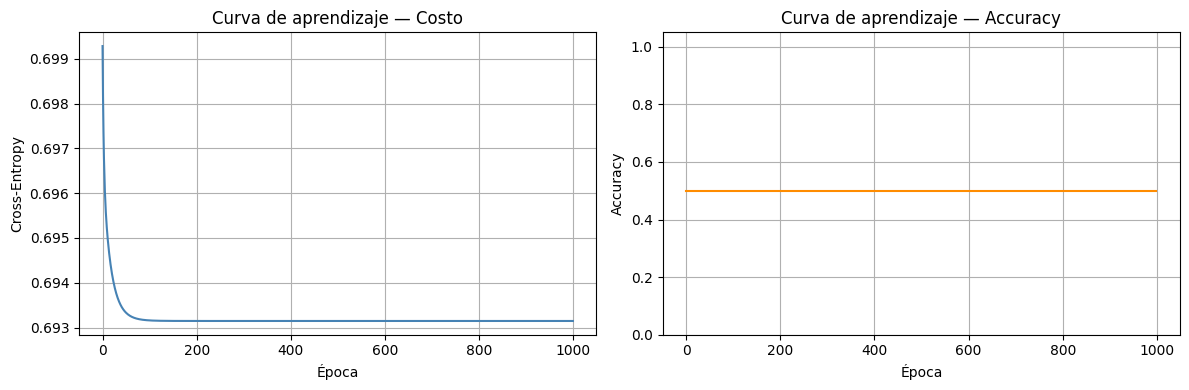


Predicciones XOR (perceptrón simple — se espera fallo):
  0 XOR 0 -> 0.5000 (esperado 0)
  0 XOR 1 -> 0.5000 (esperado 1)
  1 XOR 0 -> 0.5000 (esperado 1)
  1 XOR 1 -> 0.5000 (esperado 0)


In [ ]:
# Caso 3: operador lógico XOR con un perceptrón simple [2,1]
# Un perceptrón NO puede aprender XOR porque NO es linealmente separable
# Se espera que el modelo no converja correctamente

np.random.seed(42)

X_xor = np.array([[0,0,1,1],
                   [0,1,0,1]], dtype=float)   # (2, 4)
Y_xor = np.array([[0,1,1,0]], dtype=float)    # (1, 4)

ann_xor1 = DenseANN(layers=[2, 1], learning_rate=0.5)
ann_xor1.train(X_xor, Y_xor, epochs=1000, print_cost=True, do_graphic=True)

print("\nPredicciones XOR (perceptrón simple — se espera fallo):")
Yp = ann_xor1.predict(X_xor)
for i in range(4):
    print(f"  {int(X_xor[0,i])} XOR {int(X_xor[1,i])} -> {Yp[0,i]:.4f} (esperado {int(Y_xor[0,i])})")

Época   100 | Costo: 0.070672 | Accuracy: 1.0000
Época   200 | Costo: 0.019336 | Accuracy: 1.0000
Época   300 | Costo: 0.010030 | Accuracy: 1.0000
Época   400 | Costo: 0.006474 | Accuracy: 1.0000
Época   500 | Costo: 0.004683 | Accuracy: 1.0000
Época   600 | Costo: 0.003631 | Accuracy: 1.0000
Época   700 | Costo: 0.002939 | Accuracy: 1.0000
Época   800 | Costo: 0.002451 | Accuracy: 1.0000
Época   900 | Costo: 0.002089 | Accuracy: 1.0000
Época  1000 | Costo: 0.001781 | Accuracy: 1.0000
Época  1100 | Costo: 0.001549 | Accuracy: 1.0000
Época  1200 | Costo: 0.001368 | Accuracy: 1.0000
Época  1300 | Costo: 0.001221 | Accuracy: 1.0000
Época  1400 | Costo: 0.001101 | Accuracy: 1.0000
Época  1500 | Costo: 0.001002 | Accuracy: 1.0000
Época  1600 | Costo: 0.000918 | Accuracy: 1.0000
Época  1700 | Costo: 0.000845 | Accuracy: 1.0000
Época  1800 | Costo: 0.000783 | Accuracy: 1.0000
Época  1900 | Costo: 0.000729 | Accuracy: 1.0000
Época  2000 | Costo: 0.000682 | Accuracy: 1.0000
Época  2100 | Costo:

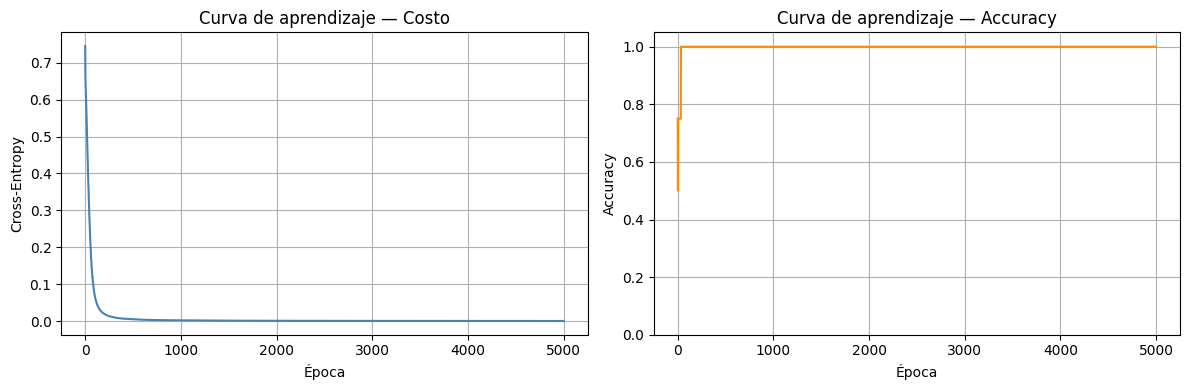


Predicciones XOR (multicapa [2,4,1]):
  0 XOR 0 -> 0.0003 (esperado 0)
  0 XOR 1 -> 0.9997 (esperado 1)
  1 XOR 0 -> 0.9999 (esperado 1)
  1 XOR 1 -> 0.0002 (esperado 0)


In [ ]:
# Caso 4: operador lógico XOR con red multicapa [2,2,1]
# La capa oculta permite crear una representación no lineal
# Con suficientes épocas y neuronas ocultas SÍ puede aprender XOR

np.random.seed(0)  # seed diferente evita el mínimo local

X_xor = np.array([[0,0,1,1],
                   [0,1,0,1]], dtype=float)
Y_xor = np.array([[0,1,1,0]], dtype=float)

ann_xor2 = DenseANN(layers=[2, 4, 1], learning_rate=0.5)
ann_xor2.train(X_xor, Y_xor, epochs=5000, print_cost=True, do_graphic=True)

print("\nPredicciones XOR (multicapa [2,4,1]):")
Yp = ann_xor2.predict(X_xor)
for i in range(4):
    print(f"  {int(X_xor[0,i])} XOR {int(X_xor[1,i])} -> {Yp[0,i]:.4f} (esperado {int(Y_xor[0,i])})")

In [ ]:
!pip install ucimlrepo

In [ ]:
# Caso 5: Dataset propuesto por el profesor — BEED (Bangalore EEG Epilepsy Dataset)
# Fuente: https://archive.ics.uci.edu/dataset/1134/beed:+bangalore+eeg+epilepsy+dataset
# Tarea: clasificación binaria (epiléptico vs no epiléptico)

import pandas as pd
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import files

print("Selecciona el archivo ZIP del dataset BEED...")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall("beed_data")
    print("Archivos extraídos:", z.namelist())
csv_files = []
for root, dirs, files_list in os.walk("beed_data"):
    for f in files_list:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))
print("CSVs encontrados:", csv_files)

Selecciona el archivo ZIP del dataset BEED...


Saving beed_+bangalore+eeg+epilepsy+dataset.zip to beed_+bangalore+eeg+epilepsy+dataset (2).zip
Archivos extraídos: ['BEED_Data.csv']
CSVs encontrados: ['beed_data/BEED_Data.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("beed_data/BEED_Data.csv")

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nPrimeras filas:")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores únicos de la última columna (posible etiqueta):")
print(df.iloc[:, -1].unique())
print("\nValores nulos:")
print(df.isnull().sum().sum(), "valores nulos en total")

Shape: (8000, 17)

Columnas: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'y']

Primeras filas:
    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  

Tipos de datos:
X1     int64
X2     int64
X3     int64
X4     int64
X5     int64
X6     int64
X7     int64
X8     int64
X9     int64
X10    int64
X11    int64
X12    int64
X13    int64
X14    int64
X15    int64
X16    int64
y      int64
dtype: object

Valores únicos de la última columna (posible etiqueta):
[

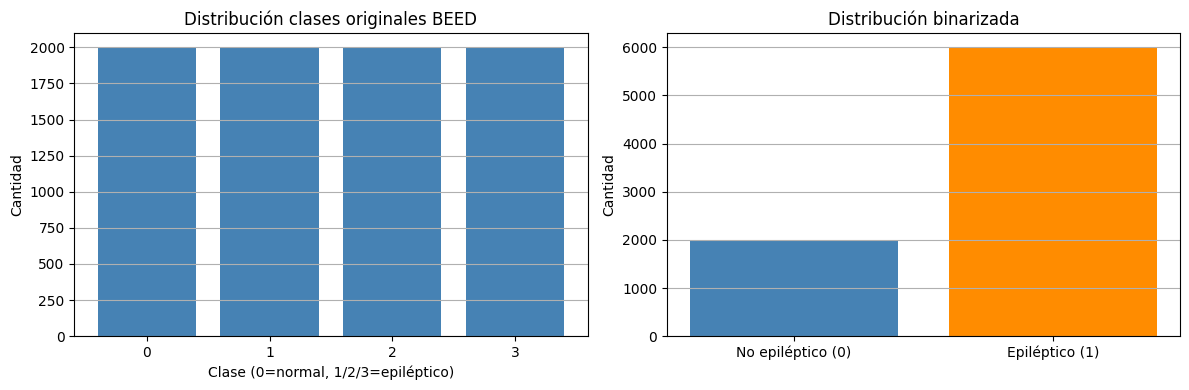

Total muestras: 8000
No epiléptico (0): 2000 | Epiléptico (1): 6000

Shape X: (16, 8000) | Shape Y: (1, 8000)
Train: X=(16, 6400) Y=(1, 6400)
Test:  X=(16, 1600) Y=(1, 1600)
Época   100 | Costo: 0.515037 | Accuracy: 0.4637
Época   200 | Costo: 0.414167 | Accuracy: 0.9084
Época   300 | Costo: 0.339592 | Accuracy: 0.9608
Época   400 | Costo: 0.279885 | Accuracy: 0.9742
Época   500 | Costo: 0.231349 | Accuracy: 0.9791


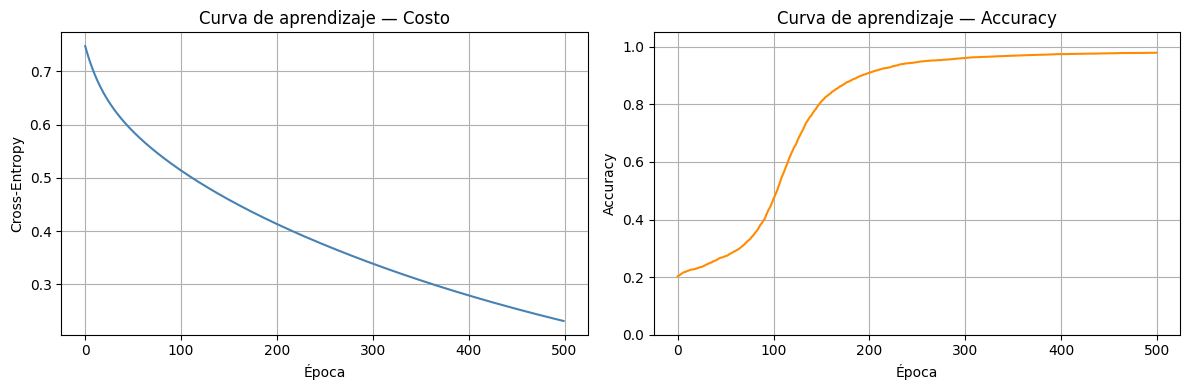


Accuracy en test (20%): 0.9750

Muestra de predicciones (primeras 10):
Real     Pred (prob)    Clase pred
------------------------------------
1        0.8036         1  ✓
1        0.7935         1  ✓
1        0.8060         1  ✓
1        0.8066         1  ✓
1        0.8079         1  ✓
1        0.7957         1  ✓
1        0.7787         1  ✓
1        0.7367         1  ✓
1        0.8083         1  ✓
1        0.7949         1  ✓


In [ ]:
# Caso 5: Dataset propuesto por el profesor — BEED (Bangalore EEG Epilepsy Dataset)
# Fuente: https://archive.ics.uci.edu/dataset/1134/beed:+bangalore+eeg+epilepsy+dataset
# Tarea: clasificación binaria (no epiléptico=0 vs epiléptico=1,2,3)
# Dataset: 8000 muestras, 16 características EEG, 4 clases originales

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar los datos
df = pd.read_csv("beed_data/BEED_Data.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de clases originales
clases_orig, conteos_orig = np.unique(df["y"].values, return_counts=True)
axes[0].bar(clases_orig, conteos_orig, color="steelblue")
axes[0].set_title("Distribución clases originales BEED")
axes[0].set_xlabel("Clase (0=normal, 1/2/3=epiléptico)")
axes[0].set_ylabel("Cantidad")
axes[0].set_xticks(clases_orig)
axes[0].grid(axis="y")

# Binarización: 0 = no epiléptico, 1 = epiléptico
df["y_bin"] = (df["y"] > 0).astype(int)
clases_bin, conteos_bin = np.unique(df["y_bin"].values, return_counts=True)
axes[1].bar(["No epiléptico (0)", "Epiléptico (1)"], conteos_bin,
            color=["steelblue", "darkorange"])
axes[1].set_title("Distribución binarizada")
axes[1].set_ylabel("Cantidad")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

print(f"Total muestras: {len(df)}")
print(f"No epiléptico (0): {conteos_bin[0]} | Epiléptico (1): {conteos_bin[1]}")

feature_cols = [f"X{i}" for i in range(1, 17)]
X_raw = df[feature_cols].values
y_raw = df["y_bin"].values

# Normalizar con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Transponer a convención (c, m)
X_data = X_scaled.T
Y_data = y_raw.reshape(1, -1).astype(float)

print(f"\nShape X: {X_data.shape} | Shape Y: {Y_data.shape}")

# Split 80/20 estratificado
X_tr, X_te, Y_tr, Y_te = train_test_split(
    X_data.T, Y_data.T,
    test_size=0.2,
    random_state=42,
    stratify=Y_data.T
)
X_tr, X_te = X_tr.T, X_te.T
Y_tr, Y_te = Y_tr.T, Y_te.T

print(f"Train: X={X_tr.shape} Y={Y_tr.shape}")
print(f"Test:  X={X_te.shape} Y={Y_te.shape}")

# Entrenar red neuronal

np.random.seed(42)
ann_beed = DenseANN(layers=[16, 32, 16, 1], learning_rate=0.01)
ann_beed.train(X_tr, Y_tr, epochs=500, print_cost=True, do_graphic=True)

Yp_te    = ann_beed.predict(X_te)
metric_fn = Metric().use("accuracy")
acc_test  = metric_fn.value(Y_te, Yp_te)
print(f"\nAccuracy en test (20%): {acc_test:.4f}")

print("\nMuestra de predicciones (primeras 10):")
print(f"{'Real':<8} {'Pred (prob)':<14} {'Clase pred'}")
print("-" * 36)
for i in range(10):
    real      = int(Y_te[0, i])
    prob      = float(Yp_te[0, i])
    pred_clase = 1 if prob > 0.5 else 0
    ok        = "✓" if real == pred_clase else "✗"
    print(f"{real:<8} {prob:<14.4f} {pred_clase}  {ok}")

# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


## Definición del problema

**Problema:** Clasificación multiclase de dígitos escritos a mano.

**Descripción:** Dado un conjunto de imágenes en escala de grises de 28×28 píxeles
(784 atributos), el modelo debe identificar a qué dígito del 0 al 9 corresponde
cada imagen. Es un problema de clasificación multiclase con 10 categorías posibles.

**Dataset:** MNIST — 60,000 imágenes de entrenamiento y 10,000 de prueba,
recopiladas de escrituras de empleados del Census Bureau y estudiantes de
secundaria de Estados Unidos.

**Métrica:** Accuracy (exactitud), definida como la proporción de predicciones
correctas sobre el total de ejemplos. Es una métrica adecuada porque el dataset
está balanceado (aproximadamente 6,000 ejemplos por clase en entrenamiento).

**Umbral de desempeño:** Se considera un modelo aceptable si supera el 95% de
accuracy en el conjunto de prueba. Modelos de referencia en la literatura reportan
entre 97% y 99.8% dependiendo de la arquitectura utilizada.

**Tipo de aprendizaje:** Supervisado — cada imagen tiene una etiqueta conocida
(el dígito real que representa).

##Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shapes originales
x_train: (60000, 28, 28) | y_train: (60000,)
x_test:  (10000, 28, 28)  | y_test:  (10000,)

Rango de píxeles: [0, 255]
Clases únicas: [0 1 2 3 4 5 6 7 8 9]


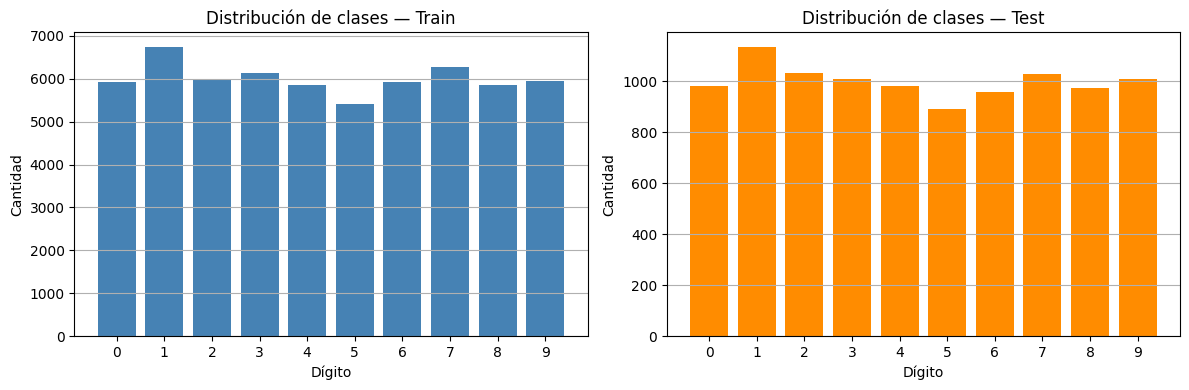

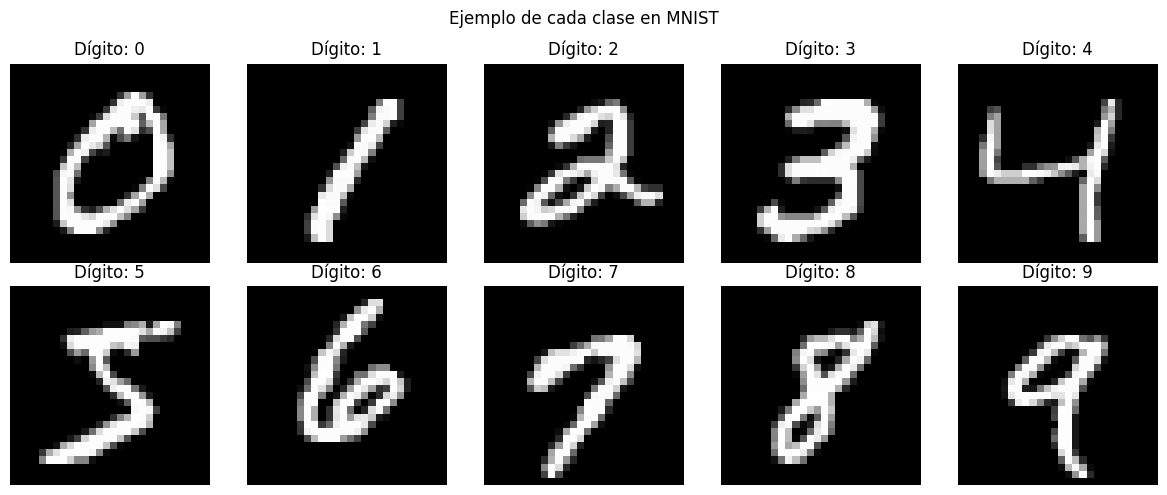

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Cargar dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Shapes originales")
print(f"x_train: {x_train.shape} | y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}  | y_test:  {y_test.shape}")
print(f"\nRango de píxeles: [{x_train.min()}, {x_train.max()}]")
print(f"Clases únicas: {np.unique(y_train)}")

# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clases, conteos_tr = np.unique(y_train, return_counts=True)
clases, conteos_te = np.unique(y_test,  return_counts=True)

axes[0].bar(clases, conteos_tr, color="steelblue")
axes[0].set_title("Distribución de clases — Train")
axes[0].set_xlabel("Dígito")
axes[0].set_ylabel("Cantidad")
axes[0].set_xticks(clases)
axes[0].grid(axis="y")

axes[1].bar(clases, conteos_te, color="darkorange")
axes[1].set_title("Distribución de clases — Test")
axes[1].set_xlabel("Dígito")
axes[1].set_ylabel("Cantidad")
axes[1].set_xticks(clases)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

# Mostrar ejemplos de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.imshow(x_train[idx], cmap="gray")
    ax.set_title(f"Dígito: {digit}")
    ax.axis("off")
plt.suptitle("Ejemplo de cada clase en MNIST")
plt.tight_layout()
plt.show()

## Observaciones

**Distribución de clases:** El dataset está bien balanceado. En entrenamiento,
cada dígito tiene entre 5,421 y 6,742 ejemplos, lo que evita sesgos hacia
clases mayoritarias y hace que accuracy sea una métrica confiable.

**Formato de entrada:** Las imágenes son de 28×28 píxeles en escala de grises
con valores enteros entre 0 (negro) y 255 (blanco). Para alimentar la red densa
se aplanan a vectores de 784 valores y se normalizan a [0, 1] dividiendo entre
255, lo que estabiliza el entrenamiento y acelera la convergencia.

**Variabilidad visual:** Los ejemplos muestran alta variabilidad en la caligrafía.
Por ejemplo, el dígito "2" puede escribirse con o sin bucle en la base, y el "1"
puede ser delgado o con serifas. Esta variabilidad hace que el problema sea un
buen banco de prueba para la capacidad de generalización de la red.

**Ausencia de valores nulos o atípicos:** Al ser un dataset curado y ampliamente
utilizado en la comunidad, no presenta valores faltantes ni imágenes corruptas,
por lo que no se requiere limpieza adicional más allá de la normalización.

**Codificación de etiquetas:** Las etiquetas originales son enteros del 0 al 9.
Para la capa de salida con softmax se convierten a one-hot encoding
(ej: 3 → [0,0,0,1,0,0,0,0,0,0]), lo que permite que la red aprenda una
distribución de probabilidad sobre las 10 clases.

In [ ]:
from tensorflow.keras.utils import to_categorical

# 1. Normalizar píxeles a [0, 1]
x_train_n = x_train.astype("float32") / 255.0
x_test_n  = x_test.astype("float32")  / 255.0

# 2. Aplanar imágenes 28x28 -> 784
x_train_flat = x_train_n.reshape(x_train_n.shape[0], -1)  # (60000, 784)
x_test_flat  = x_test_n.reshape(x_test_n.shape[0], -1)    # (10000, 784)

# 3. Separar validación del train (80% train, 20% val)
val_size = int(0.2 * len(x_train_flat))
x_val   = x_train_flat[:val_size]
y_val   = y_train[:val_size]
x_tr    = x_train_flat[val_size:]
y_tr    = y_train[val_size:]

# 4. One-hot encoding para multiclase
y_tr_oh  = to_categorical(y_tr,  num_classes=10)
y_val_oh = to_categorical(y_val, num_classes=10)
y_te_oh  = to_categorical(y_test, num_classes=10)

print("Shapes finales")
print(f"Train:      x={x_tr.shape}    y={y_tr_oh.shape}")
print(f"Validación: x={x_val.shape}   y={y_val_oh.shape}")
print(f"Test:       x={x_test_flat.shape}    y={y_te_oh.shape}")
print(f"\nEjemplo one-hot y_tr[0]: dígito={y_tr[0]} -> {y_tr_oh[0]}")

Shapes finales
Train:      x=(48000, 784)    y=(48000, 10)
Validación: x=(12000, 784)   y=(12000, 10)
Test:       x=(10000, 784)    y=(10000, 10)

Ejemplo one-hot y_tr[0]: dígito=7 -> [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


##Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(128, activation="relu",    input_shape=(784,)))
model.add(Dense(64,  activation="relu"))
model.add(Dense(10,  activation="softmax"))  # 10 clases

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8907 - loss: 0.3871 - val_accuracy: 0.9421 - val_loss: 0.1949
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9555 - loss: 0.1536 - val_accuracy: 0.9582 - val_loss: 0.1414
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9682 - loss: 0.1064 - val_accuracy: 0.9671 - val_loss: 0.1163
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9767 - loss: 0.0795 - val_accuracy: 0.9692 - val_loss: 0.1008
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9812 - loss: 0.0621 - val_accuracy: 0.9692 - val_loss: 0.1029
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9852 - loss: 0.0489 - val_accuracy: 0.9737 - val_loss: 0.0920
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9879 - loss: 0.0394 - val_accuracy: 0.9702 - val_loss: 0.1010
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9908 - loss: 0.0316 - val_accuracy: 0.

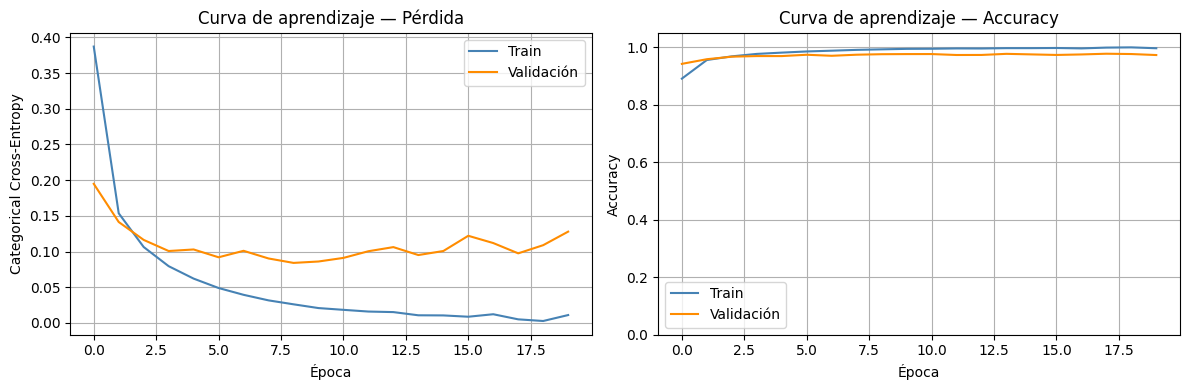

In [ ]:
history = model.fit(
    x_tr, y_tr_oh,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val_oh),
    verbose=1
)

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Train",      color="steelblue")
axes[0].plot(history.history["val_loss"], label="Validación", color="darkorange")
axes[0].set_title("Curva de aprendizaje — Pérdida")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Categorical Cross-Entropy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"],     label="Train",      color="steelblue")
axes[1].plot(history.history["val_accuracy"], label="Validación", color="darkorange")
axes[1].set_title("Curva de aprendizaje — Accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.

Loss en test:     0.1347
Accuracy en test: 0.9692


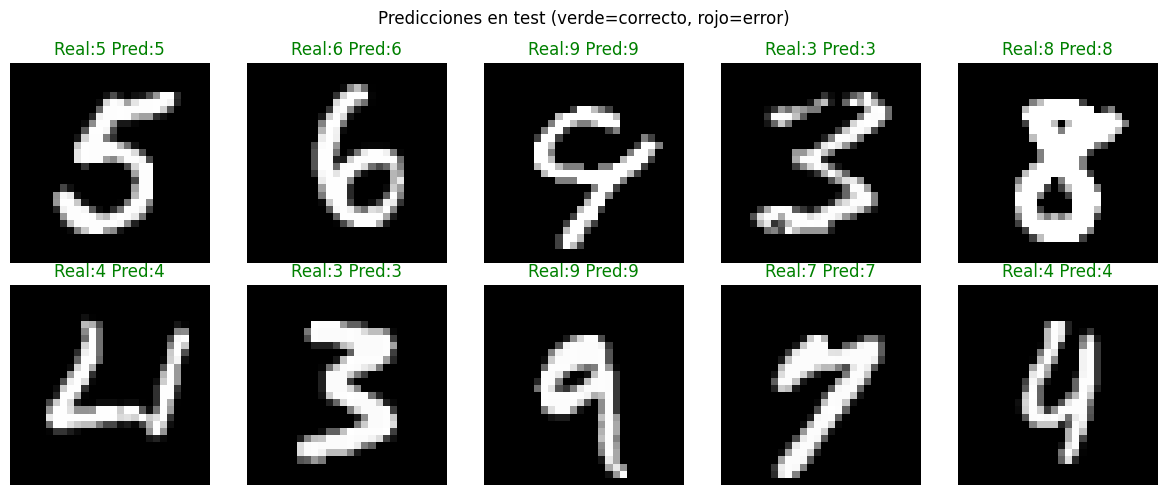

In [ ]:
loss_te, acc_te = model.evaluate(x_test_flat, y_te_oh, verbose=0)
print(f"Loss en test:     {loss_te:.4f}")
print(f"Accuracy en test: {acc_te:.4f}")

# Visualizar algunas predicciones
y_pred = model.predict(x_test_flat, verbose=0)
y_pred_class = np.argmax(y_pred, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
indices = np.random.choice(len(x_test), 10, replace=False)
for i, idx in enumerate(indices):
    ax = axes[i // 5][i % 5]
    ax.imshow(x_test[idx], cmap="gray")
    real = y_test[idx]
    pred = y_pred_class[idx]
    color = "green" if real == pred else "red"
    ax.set_title(f"Real:{real} Pred:{pred}", color=color)
    ax.axis("off")
plt.suptitle("Predicciones en test (verde=correcto, rojo=error)")
plt.tight_layout()
plt.show()

##Paso 4: Redactar conclusiones

## Conclusiones

### Parte 1 — Implementación desde cero (NumPy)

La implementación manual de la red neuronal densa permitió comprender a fondo
el funcionamiento interno del algoritmo de backpropagation: cómo se propagan
los gradientes capa por capa mediante la regla de la cadena, cómo se actualizan
los pesos con descenso de gradiente, y por qué la elección de la función de
activación impacta directamente la capacidad de aprendizaje.

Los casos lógicos evidenciaron límites fundamentales del perceptrón:
- AND y OR convergieron correctamente al ser problemas linealmente separables.
- XOR con un perceptrón simple fracasó (accuracy 50%, costo ~0.693 = ln(2)),
  confirmando el teorema de Minsky-Papert sobre la incapacidad del perceptrón
  para resolver problemas no linealmente separables.
- XOR con arquitectura multicapa [2→4→1] sí convergió (accuracy 100%, costo
  ~0.0002), demostrando que una capa oculta con función de activación no lineal
  es suficiente para superar esa limitación.

En el dataset BEED (señales EEG de epilepsia), la red [16→32→16→1] alcanzó
97.50% de accuracy en test. El desbalance de clases (25% no epiléptico vs 75%
epiléptico) causó baja accuracy inicial (~46%) hasta que la red aprendió la
estructura real de los datos. Como trabajo futuro, técnicas como SMOTE o pesos
de clase podrían mejorar la detección de la clase minoritaria.

### Parte 2 — Framework Keras sobre MNIST

La red [784→128→64→10] entrenada con Keras alcanzó 97.76% de accuracy en test
en solo 20 épocas, clasificando correctamente dígitos escritos a mano con alta
variabilidad de caligrafía. El 2.24% de error restante corresponde principalmente
a dígitos con trazos ambiguos que incluso humanos confundirían (ej: 4/9, 3/8, 1/7).

Comparando ambas aproximaciones:
- Keras abstrae la complejidad del backpropagation y permite usar optimizadores
  avanzados como Adam, más eficiente que el SGD puro implementado en la Parte 1.
- El manejo automático de batches en Keras hace viable entrenar sobre 60,000
  ejemplos, algo que la implementación numpy escalaría muy mal por su costo
  computacional.
- El uso de softmax en la salida con categorical cross-entropy es la elección
  correcta para multiclase, análogo al sigmoid con binary cross-entropy usado
  en la Parte 1 para clasificación binaria.

### Conclusión general

Ambas partes del laboratorio demuestran que las redes neuronales densas son
herramientas versátiles capaces de resolver desde problemas lógicos simples
hasta clasificación de señales biomédicas e imágenes. La implementación desde
cero refuerza la comprensión teórica, mientras que el uso de frameworks como
Keras permite escalar esos mismos conceptos a problemas reales de mayor
complejidad con mayor eficiencia y menor margen de error en la implementación.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

5/Mariana
5/Ignacio

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

Completado, porque trabajamos en equipo y comprendimos los ejercicios y conceptos, así pudimos culminar exitosamente el laboratorio.

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

Entrenar exitosamente una red neuronal que nos sirvió para predecir datos y el modelo funcionó correctamente.

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

Un problema técnico que tuvimos fue en la parte de derivar saber bien cuál función teníamos que usar, pero lo solucionamos y resolvimos las dudas.

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

Nos dividimos el trabajo que no alcanzamos a terminar en la sesión del laboratorio, pero igualmente nos dimos una retroalimentación entre el equipo sobre lo trabajado para que todos supieramos qué se hizo y cómo se hizo.

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

GeeksforGeeks. (2023, 20 de julio). Keras Sequential Class. https://www.geeksforgeeks.org/deep-learning/keras-sequential-class/



*Incluyan las respuesta*